# PoC4 — reliability-aware adaptive fusion versus best fixed fusion

This notebook tests whether the adaptive component itself has scientific
value. The primary comparison is:

`PoC4 reliability-aware fusion` versus `best fixed-weight fusion`.

The temporal and CWT experts are frozen to the previously validated small
architectures and training schedule as far as possible. Previous PoC1,
PoC2, and PoC3 notebooks and outputs are not modified.

## Objective, hypothesis, and decision criteria

**Hypothesis.** The relative reliability of the temporal and CWT experts
varies by sample and can be estimated from predictions, low-dimensional
representation summaries, and signal descriptors well enough to improve
an optimally tuned global fixed fusion.

**Primary quantity.** `ΔMCC = MCC(adaptive) − MCC(best fixed)`.

**Strong GO:** `ΔMCC >= +0.005`, paired 95% bootstrap interval entirely
above zero, at least 4/5 positive seeds, net error reduction, meaningful
reliability prediction, and no important PD-recall degradation.

**Moderate GO:** `+0.002 <= ΔMCC < +0.005` with consistency, statistical
support, interpretable reliability, and useful robustness evidence.

Otherwise the notebook returns **NO-GO FOR ADAPTIVE FUSION**. A NO-GO
does not reject complementary temporal/CWT fusion; it only rejects a
demonstrated added value of sample-wise reliability over static fusion.

## Experimental constraints and split policy

The PoC uses `Tr0` for expert training and OOF construction, `Va0` for
calibration, threshold/model selection, and `Te0` for the locked
exploratory evaluation. `Te1` and `Te2` are not used for any PoC4
decision. In particular:

> **Te2 is reserved for a future confirmatory experiment and is not
> accessed in this PoC.**

The loader below has an allow-list that excludes `Te2.mat`, and the
final test-load cell is intentionally placed after the frozen-config
cell. No raw data are copied into the repository; the external catalog
is resolved through `PD_DATASETS_CATALOG_ROOT`.

In [1]:
import gc
import json
import math
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
import random
import struct
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.io import loadmat
from scipy.stats import binomtest
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (PROJECT_ROOT / 'data' / 'datasets.yaml').is_file():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
if not ((PROJECT_ROOT / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (PROJECT_ROOT / 'data' / 'datasets.yaml').is_file()):
    raise RuntimeError('Run this notebook from the repository or a child directory.')

CATALOG_ROOT_VALUE = os.environ.get('PD_DATASETS_CATALOG_ROOT')
if not CATALOG_ROOT_VALUE:
    raise RuntimeError('Set PD_DATASETS_CATALOG_ROOT to the external datasets_catalog.')
CATALOG_ROOT = Path(CATALOG_ROOT_VALUE).expanduser().resolve()
DATASET_ID, DATASET_VERSION = 'engineering-partial-discharge-noise-signals', 'v1'
DATASET_ROOT = CATALOG_ROOT / 'data' / 'raw' / 'dataset-pd-noise'
RESULT_DIR = PROJECT_ROOT / 'poc' / 'results'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 43, 44, 45, 46]
TEMPORAL_EPOCHS, CWT_EPOCHS = 9, 5
BATCH_SIZE, INFERENCE_BATCH_SIZE = 128, 1024
TORCH_THREADS, N_BOOTSTRAP_PER_SEED = 1, 2000
N_BOOTSTRAP_TOTAL = len(SEEDS) * N_BOOTSTRAP_PER_SEED
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(TORCH_THREADS)
torch.use_deterministic_algorithms(True)

# Te2 is intentionally absent from this allow-list. Do not add it here.
ALLOWED_PARTITIONS = ('Tr0.mat', 'Va0.mat', 'Te0.mat')
FORBIDDEN_PARTITION = 'Te2.mat'
EXPECTED_COUNTS = {
    'Tr0.mat': {0: 6130, 1: 6130},
    'Va0.mat': {0: 1533, 1: 1533},
    'Te0.mat': {0: 22985, 1: 22985},
}
loaded_partitions = []

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def git_commit():
    try:
        return subprocess.check_output(['git', '-C', str(PROJECT_ROOT), 'rev-parse', 'HEAD'], text=True).strip()
    except Exception:
        return 'unavailable'

def decode_labels(workspace, n_samples):
    raw = np.asarray(workspace, dtype=np.uint8).reshape(-1).tobytes()
    marker = bytes([16, 0, 2, 0]) + b'PD'
    if b'NonPD' not in raw or marker not in raw:
        raise ValueError('MATLAB categorical labels not found.')
    needle, candidates, offset = struct.pack('<II', 2, n_samples), [], 0
    while True:
        position = raw.find(needle, offset)
        if position < 0:
            break
        start = position + len(needle)
        codes = np.frombuffer(raw, dtype=np.uint8, count=n_samples, offset=start).copy()
        if codes.size == n_samples and np.all(np.isin(codes, [1, 2])):
            candidates.append(codes)
        offset = position + 1
    if len(candidates) != 1:
        raise ValueError(f'Could not identify unique labels: {len(candidates)}')
    return (candidates[0] == 2).astype(np.int64)

def load_partition(file_id):
    if file_id not in ALLOWED_PARTITIONS:
        raise ValueError(f'{file_id} is outside PoC4 scope; Te2 is reserved and cannot be loaded.')
    table = Path(file_id).stem
    mat = loadmat(DATASET_ROOT / file_id, squeeze_me=False, struct_as_record=False, variable_names=[table, '__function_workspace__'])
    record = mat[table][0, 0]
    signals = np.stack([np.asarray(item, dtype=np.float32).reshape(-1) for item in np.asarray(record.signals, dtype=object).reshape(-1)])
    labels = decode_labels(mat['__function_workspace__'], len(signals))
    counts = dict(sorted(Counter(labels.tolist()).items()))
    expected_n = sum(EXPECTED_COUNTS[file_id].values())
    if signals.shape != (expected_n, 400):
        raise ValueError(f'{file_id}: bad signal shape {signals.shape}')
    if counts != EXPECTED_COUNTS[file_id]:
        raise ValueError(f'{file_id}: bad counts {counts}')
    loaded_partitions.append(file_id)
    return signals, labels

print('Python:', sys.version.replace('\n', ' '))
print('Executable:', sys.executable)
print('Environment:', os.environ.get('CONDA_DEFAULT_ENV', 'not reported'))
print('PyTorch:', torch.__version__, '| NumPy:', np.__version__, '| pandas:', pd.__version__)
print('Device:', DEVICE, '| threads:', torch.get_num_threads())
print('Catalog:', CATALOG_ROOT)
print('Commit:', git_commit())
print('Protocol: Tr0/Va0 development; Te0 locked after freeze; Te2 excluded.')

X_train, y_train = load_partition('Tr0.mat')
X_val, y_val = load_partition('Va0.mat')
assert FORBIDDEN_PARTITION not in loaded_partitions
display(pd.DataFrame([
    {'partition': 'Tr0.mat', 'n': len(y_train), 'NonPD': int((y_train == 0).sum()), 'PD': int((y_train == 1).sum())},
    {'partition': 'Va0.mat', 'n': len(y_val), 'NonPD': int((y_val == 0).sum()), 'PD': int((y_val == 1).sum())},
]))

Python: 3.11.16 | packaged by conda-forge | (main, Aug 21 2026, 22:44:51) [GCC 14.4.0]
Executable: /home/polivares/.local/share/mamba/envs/partial-discharge/bin/python
Environment: partial-discharge
PyTorch: 2.9.1 | NumPy: 2.4.6 | pandas: 3.0.5
Device: cuda | threads: 1
Catalog: /home/polivares/Dropbox/Work/Research/datasets_catalog
Commit: acfe24dd316150c3228a23e30fceafc637d1dcbb
Protocol: Tr0/Va0 development; Te0 locked after freeze; Te2 excluded.


,partition,n,NonPD,PD
0,Tr0.mat,12260,6130,6130
1,Va0.mat,3066,1533,1533


## Frozen representations and leakage-safe reliability summaries

The temporal branch uses the standardized raw 400-sample signal. The
second branch reuses PoC3's fixed complex-Morlet CWT/log-power setup.
Its cache is reused only when its metadata exactly match; otherwise a
new development-only cache is built. Standardization is fitted on
`Tr0` only.

Reliability features are intentionally small and interpretable:
prediction/logit margins, entropy, cross-expert disagreement, signal
descriptors, and distances to class centroids in fixed low-dimensional
temporal/CWT summary embeddings. OOF centroid distances are computed
against other folds, so the held-out OOF row does not contribute to its
own label-derived centroid feature.

In [2]:
def fit_standardizer(values):
    mean = values.mean(axis=0, keepdims=True).astype(np.float32)
    std = values.std(axis=0, keepdims=True).astype(np.float32)
    std[std < 1e-6] = 1.0
    return mean, std

CWT_W0 = 6.0
CWT_SCALES = np.geomspace(1.5, 64.0, 32).astype(np.float32)
CWT_TIME_BINS, CWT_FLOOR, CWT_EPS = 120, -10.0, 1e-8
CWT_INDEX = np.linspace(0, 399, CWT_TIME_BINS).round().astype(int)
CWT_SHAPE = (len(CWT_SCALES), CWT_TIME_BINS)

def cwt_log_batch(values):
    values = np.asarray(values, dtype=np.float32)
    signal_fft = np.fft.fft(values, axis=1)
    centered = np.arange(400, dtype=np.float64) - 200
    result = np.empty((len(values), *CWT_SHAPE), dtype=np.float32)
    for scale_index, scale in enumerate(CWT_SCALES.astype(np.float64)):
        wavelet = np.exp(-0.5 * (centered / scale) ** 2) * np.exp(1j * CWT_W0 * centered / scale) / np.sqrt(scale)
        kernel = np.conj(np.fft.fft(np.fft.ifftshift(wavelet)))
        coefficients = np.fft.ifft(signal_fft * kernel[None, :], axis=1)
        result[:, scale_index, :] = np.maximum(np.log(np.abs(coefficients[:, CWT_INDEX]) ** 2 + CWT_EPS), CWT_FLOOR)
    return result.astype(np.float32)

X_dev = np.concatenate([X_train, X_val], axis=0)
y_dev = np.concatenate([y_train, y_val], axis=0)
train_indices = np.arange(len(X_train), dtype=np.int64)
val_indices = np.arange(len(X_train), len(X_dev), dtype=np.int64)
raw_mean, raw_std = fit_standardizer(X_train)

CWT_META = {
    'shape': [len(X_dev), CWT_SHAPE[0], CWT_SHAPE[1]],
    'dtype': 'float16',
    'wavelet': 'complex Morlet',
    'morlet_w0': CWT_W0,
    'scales': [float(x) for x in CWT_SCALES],
    'time_bins': CWT_TIME_BINS,
    'clip_floor': CWT_FLOOR,
    'source': 'Tr0/Va0 only',
}
cache_candidates = [
    (RESULT_DIR / 'poc3_cwt_tr0_va0_log_float16.dat', RESULT_DIR / 'poc3_cwt_tr0_va0_cache_meta.json'),
    (RESULT_DIR / 'poc4_cwt_tr0_va0_log_float16.dat', RESULT_DIR / 'poc4_cwt_tr0_va0_cache_meta.json'),
]
cwt_path = cwt_meta_path = None
for candidate_path, candidate_meta_path in cache_candidates:
    valid = False
    if candidate_path.is_file() and candidate_meta_path.is_file():
        try:
            valid = json.loads(candidate_meta_path.read_text()) == CWT_META
            valid = valid and candidate_path.stat().st_size == int(np.prod(CWT_META['shape']) * np.dtype(np.float16).itemsize)
        except Exception:
            valid = False
    if valid:
        cwt_path, cwt_meta_path = candidate_path, candidate_meta_path
        break
if cwt_path is None:
    cwt_path, cwt_meta_path = cache_candidates[-1]
    cwt_cache = np.memmap(cwt_path, dtype=np.float16, mode='w+', shape=tuple(CWT_META['shape']))
    for start in range(0, len(X_dev), 1024):
        stop = min(start + 1024, len(X_dev))
        cwt_cache[start:stop] = cwt_log_batch(X_dev[start:stop]).astype(np.float16)
    cwt_cache.flush()
    cwt_meta_path.write_text(json.dumps(CWT_META, indent=2, sort_keys=True))
    print('Generated development CWT cache:', cwt_path)
else:
    cwt_cache = np.memmap(cwt_path, dtype=np.float16, mode='r', shape=tuple(CWT_META['shape']))
    print('Reused validated development CWT cache:', cwt_path)

def fit_cwt_standardizer(cache, indices, chunk_size=2048):
    total = np.zeros(CWT_SHAPE, dtype=np.float64)
    total_sq = np.zeros(CWT_SHAPE, dtype=np.float64)
    indices = np.asarray(indices, dtype=np.int64)
    for start in range(0, len(indices), chunk_size):
        batch = np.asarray(cache[indices[start:start + chunk_size]], dtype=np.float32)
        total += batch.sum(axis=0)
        total_sq += np.square(batch, dtype=np.float64).sum(axis=0)
    mean = total / len(indices)
    variance = np.maximum(total_sq / len(indices) - mean * mean, 1e-6)
    return mean.astype(np.float32), np.sqrt(variance).astype(np.float32)

cwt_mean, cwt_std = fit_cwt_standardizer(cwt_cache, train_indices)

def sigmoid(logits):
    return 1.0 / (1.0 + np.exp(-np.clip(np.asarray(logits, dtype=np.float64), -40, 40)))

def normalized_entropy(probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1.0 - 1e-7)
    return -(probability * np.log2(probability) + (1.0 - probability) * np.log2(1.0 - probability))

def signal_features(values):
    values = np.asarray(values, dtype=np.float64)
    centered = values - values.mean(axis=1, keepdims=True)
    std = values.std(axis=1) + 1e-8
    rms = np.sqrt(np.mean(values * values, axis=1))
    peak = np.max(np.abs(values), axis=1)
    energy = np.sum(values * values, axis=1) / values.shape[1]
    skew = np.mean(centered ** 3, axis=1) / (std ** 3)
    kurt = np.mean(centered ** 4, axis=1) / (std ** 4) - 3.0
    spectrum = np.abs(np.fft.rfft(values, axis=1)) + 1e-12
    power = spectrum ** 2
    freq = np.arange(power.shape[1], dtype=np.float64)[None, :] / max(power.shape[1] - 1, 1)
    centroid = (power * freq).sum(axis=1) / power.sum(axis=1)
    spectral_prob = power / power.sum(axis=1, keepdims=True)
    spectral_entropy = -(spectral_prob * np.log(spectral_prob)).sum(axis=1) / np.log(power.shape[1])
    hf_ratio = power[:, int(0.25 * power.shape[1]):].sum(axis=1) / power.sum(axis=1)
    return np.column_stack([
        rms, peak, energy, std, skew, kurt, peak / (rms + 1e-8),
        centroid, spectral_entropy, hf_ratio,
    ]).astype(np.float64)

SIGNAL_FEATURE_NAMES = ['rms', 'peak_abs', 'energy', 'std', 'skewness', 'kurtosis', 'crest_factor', 'spectral_centroid', 'spectral_entropy', 'high_frequency_ratio']

def temporal_embedding(values):
    blocks = np.asarray(values, dtype=np.float32).reshape(-1, 20, 20)
    return np.concatenate([blocks.mean(axis=2), blocks.std(axis=2)], axis=1).astype(np.float64)

def cwt_embedding(values):
    # 32 scales × 120 times -> 8 scale groups × 8 time groups.
    pooled = np.asarray(values, dtype=np.float32).reshape(-1, 8, 4, 8, 15).mean(axis=(2, 4))
    return pooled.reshape(len(values), -1).astype(np.float64)

emb_t_train = temporal_embedding(X_train)
emb_t_val = temporal_embedding(X_val)
emb_c_train = cwt_embedding(cwt_cache[:len(X_train)])
emb_c_val = cwt_embedding(cwt_cache[len(X_train):])
signal_train = signal_features(X_train)
signal_val = signal_features(X_val)
print('Embeddings:', emb_t_train.shape, emb_c_train.shape, '| signal features:', signal_train.shape)

Reused validated development CWT cache: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc3_cwt_tr0_va0_log_float16.dat


Embeddings: (12260, 40) (12260, 64) | signal features: (12260, 10)


## Frozen expert definitions

Both experts use the small architectures from PoC3. The temporal model
is unchanged from PoC1/PoC3; CWT uses the fixed 2D CNN from PoC3. The
expert schedule is frozen to the validated PoC3 checkpoint epochs
(temporal 9, CWT 5), so the five-seed experiment does not optimize the
base experts. The data are balanced, so no class reweighting is used.

In [3]:
class TinyTemporalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, x, return_embedding=False):
        embedding = self.features(x).squeeze(-1)
        logits = self.classifier(embedding).squeeze(-1)
        return (logits, embedding) if return_embedding else logits

class SmallCWT2DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, x, return_embedding=False):
        embedding = self.features(x).flatten(1)
        logits = self.classifier(embedding).squeeze(-1)
        return (logits, embedding) if return_embedding else logits

class ExpertDataset(Dataset):
    def __init__(self, values, labels, indices, mean, std, kind):
        self.values = values
        self.labels = labels
        self.indices = np.asarray(indices, dtype=np.int64)
        self.mean = mean.astype(np.float32)
        self.std = std.astype(np.float32)
        self.kind = kind

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        index = int(self.indices[position])
        x = np.asarray(self.values[index], dtype=np.float32)
        if self.kind == 'temporal':
            x = (x - self.mean.reshape(-1)) / self.std.reshape(-1)
        else:
            x = (x - self.mean) / self.std
        x = x[None] if self.kind == 'temporal' else x[None]
        return torch.from_numpy(x.astype(np.float32)), torch.tensor(float(self.labels[index]), dtype=torch.float32)

def new_model(kind):
    return (TinyTemporalCNN() if kind == 'temporal' else SmallCWT2DCNN()).to(DEVICE)

def predict_logits(model, dataset):
    loader = DataLoader(dataset, batch_size=INFERENCE_BATCH_SIZE, shuffle=False, num_workers=0)
    model.eval()
    values = []
    with torch.no_grad():
        for x, _ in loader:
            values.append(model(x.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(values).astype(np.float64)

def train_fixed_expert(kind, seed):
    set_seed(seed)
    model = new_model(kind)
    values = X_train if kind == 'temporal' else cwt_cache
    mean, std = (raw_mean, raw_std) if kind == 'temporal' else (cwt_mean, cwt_std)
    train_ds = ExpertDataset(values, y_train, train_indices, mean, std, kind)
    val_ds = ExpertDataset(values if kind == 'temporal' else cwt_cache, y_val, np.arange(len(X_val)), mean, std, kind)
    # For CWT validation indices are local to the validation view.
    if kind == 'cwt':
        val_ds = ExpertDataset(cwt_cache[len(X_train):], y_val, np.arange(len(X_val)), mean, std, kind)
    loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()
    epochs = TEMPORAL_EPOCHS if kind == 'temporal' else CWT_EPOCHS
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x, y in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(x.to(DEVICE)), y.to(DEVICE))
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        val_logits = predict_logits(model, val_ds)
        history.append({
            'epoch': epoch,
            'train_loss': float(np.mean(losses)),
            'val_mcc_at_0.5': float(matthews_corrcoef(y_val, val_logits >= 0)),
        })
    return model, history

print('Model parameters:', sum(p.numel() for p in TinyTemporalCNN().parameters()), 'temporal;', sum(p.numel() for p in SmallCWT2DCNN().parameters()), 'CWT')

Model parameters: 13313 temporal; 23585 CWT


## OOF reliability data and oracle complementarity

PoC3 produced five-fold cross-fitted OOF logits for the same `Tr0`
development partition. We reuse that cache only after checking its
row identity and fold coverage; it contains no in-sample predictions.
These OOF predictions train the reliability estimators and the PoC3
gate. All final-seed experts below are independently retrained on
`Tr0` and selected only with `Va0`. The cached OOF set is the validated
PoC3 seed-42 OOF run and is held fixed across the five final expert
seeds; this isolates base-expert stochasticity, but is a limitation
relative to a full independent OOF retrain for every seed.

In [4]:
oof_path = RESULT_DIR / 'poc3_gate_oof_predictions.csv'
if not oof_path.is_file():
    raise FileNotFoundError('Validated PoC3 OOF predictions are required for PoC4.')
oof = pd.read_csv(oof_path)
required_oof_columns = {'sample_id', 'partition', 'true_label', 'fold_id', 'temporal_logit_oof', 'cwt_logit_oof'}
if not required_oof_columns.issubset(oof.columns):
    raise ValueError(f'OOF cache missing columns: {required_oof_columns - set(oof.columns)}')
oof['_index'] = oof['sample_id'].str.split(':').str[-1].astype(int)
oof = oof.sort_values('_index').reset_index(drop=True)
assert np.array_equal(oof['_index'].to_numpy(), np.arange(len(X_train)))
assert (oof['partition'] == 'Tr0').all()
assert sorted(oof['fold_id'].unique().tolist()) == [1, 2, 3, 4, 5]
oof_y = oof['true_label'].to_numpy(dtype=np.int64)
assert np.array_equal(oof_y, y_train)
oof_t = oof['temporal_logit_oof'].to_numpy(dtype=np.float64)
oof_c = oof['cwt_logit_oof'].to_numpy(dtype=np.float64)
oof_folds = oof['fold_id'].to_numpy(dtype=np.int64)
oof_p_t, oof_p_c = sigmoid(oof_t), sigmoid(oof_c)
oof_pred_t, oof_pred_c = (oof_p_t >= 0.5).astype(int), (oof_p_c >= 0.5).astype(int)

def fit_embedding_scale(embedding):
    mean = embedding.mean(axis=0)
    std = embedding.std(axis=0)
    std[std < 1e-8] = 1.0
    return mean, std

emb_t_mean, emb_t_std = fit_embedding_scale(emb_t_train)
emb_c_mean, emb_c_std = fit_embedding_scale(emb_c_train)

def centroid_distances(reference_embedding, reference_labels, query_embedding, mean, std):
    ref = (reference_embedding - mean) / std
    query = (query_embedding - mean) / std
    centroids = np.stack([ref[reference_labels == cls].mean(axis=0) for cls in [0, 1]])
    return np.column_stack([
        np.sqrt(np.mean((query - centroids[0]) ** 2, axis=1)),
        np.sqrt(np.mean((query - centroids[1]) ** 2, axis=1)),
    ])

def oof_centroid_distances(embedding, labels, folds, mean, std):
    result = np.empty((len(embedding), 2), dtype=np.float64)
    for fold in sorted(np.unique(folds)):
        holdout = folds == fold
        fit = ~holdout
        result[holdout] = centroid_distances(embedding[fit], labels[fit], embedding[holdout], mean, std)
    return result

oof_dist_t = oof_centroid_distances(emb_t_train, y_train, oof_folds, emb_t_mean, emb_t_std)
oof_dist_c = oof_centroid_distances(emb_c_train, y_train, oof_folds, emb_c_mean, emb_c_std)
train_dist_t = centroid_distances(emb_t_train, y_train, emb_t_train, emb_t_mean, emb_t_std)
train_dist_c = centroid_distances(emb_c_train, y_train, emb_c_train, emb_c_mean, emb_c_std)
val_dist_t = centroid_distances(emb_t_train, y_train, emb_t_val, emb_t_mean, emb_t_std)
val_dist_c = centroid_distances(emb_c_train, y_train, emb_c_val, emb_c_mean, emb_c_std)

def reliability_features(logit_t, logit_c, prob_t, prob_c, embedding_dist_t, embedding_dist_c, signal_values):
    prob_t, prob_c = np.asarray(prob_t), np.asarray(prob_c)
    pred_t, pred_c = (prob_t >= 0.5).astype(int), (prob_c >= 0.5).astype(int)
    parts = [
        np.asarray(logit_t)[:, None], np.asarray(logit_c)[:, None],
        prob_t[:, None], prob_c[:, None],
        np.abs(prob_t - 0.5)[:, None], np.abs(prob_c - 0.5)[:, None],
        normalized_entropy(prob_t)[:, None], normalized_entropy(prob_c)[:, None],
        np.maximum(prob_t, 1 - prob_t)[:, None], np.maximum(prob_c, 1 - prob_c)[:, None],
        np.abs(prob_t - prob_c)[:, None], (prob_t - prob_c)[:, None],
        (pred_t == pred_c).astype(float)[:, None],
        embedding_dist_t, embedding_dist_c,
        (embedding_dist_t[:, 0] - embedding_dist_t[:, 1])[:, None],
        (embedding_dist_c[:, 0] - embedding_dist_c[:, 1])[:, None],
        signal_values,
    ]
    return np.nan_to_num(np.column_stack(parts), nan=0.0, posinf=1e6, neginf=-1e6).astype(np.float64)

FEATURE_NAMES = [
    'temporal_logit', 'cwt_logit', 'temporal_probability', 'cwt_probability',
    'temporal_margin', 'cwt_margin', 'temporal_entropy', 'cwt_entropy',
    'temporal_confidence', 'cwt_confidence', 'absolute_probability_difference',
    'signed_probability_difference', 'expert_agreement', 'temporal_distance_class0',
    'temporal_distance_class1', 'cwt_distance_class0', 'cwt_distance_class1',
    'temporal_centroid_margin', 'cwt_centroid_margin', *SIGNAL_FEATURE_NAMES,
]
oof_features = reliability_features(oof_t, oof_c, oof_p_t, oof_p_c, oof_dist_t, oof_dist_c, signal_train)
assert oof_features.shape[1] == len(FEATURE_NAMES)
correct_oof_t = (oof_pred_t == y_train).astype(int)
correct_oof_c = (oof_pred_c == y_train).astype(int)

def oracle_prediction(labels, pred_t, pred_c):
    t_correct, c_correct = pred_t == labels, pred_c == labels
    return np.where((~t_correct) & c_correct, pred_c, pred_t).astype(int)

def complementarity_summary(labels, pred_t, pred_c, fixed_pred=None):
    both_correct = (pred_t == labels) & (pred_c == labels)
    both_wrong = (pred_t != labels) & (pred_c != labels)
    t_only = (pred_t == labels) & (pred_c != labels)
    c_only = (pred_t != labels) & (pred_c == labels)
    oracle = oracle_prediction(labels, pred_t, pred_c)
    result = {
        'n': int(len(labels)),
        'both_correct_fraction': float(both_correct.mean()),
        'both_wrong_fraction': float(both_wrong.mean()),
        'temporal_correct_cwt_wrong_fraction': float(t_only.mean()),
        'cwt_correct_temporal_wrong_fraction': float(c_only.mean()),
        'disagreement_fraction': float((pred_t != pred_c).mean()),
        'temporal_mcc': float(matthews_corrcoef(labels, pred_t)),
        'cwt_mcc': float(matthews_corrcoef(labels, pred_c)),
        'oracle_mcc': float(matthews_corrcoef(labels, oracle)),
    }
    if fixed_pred is not None:
        result['fixed_mcc'] = float(matthews_corrcoef(labels, fixed_pred))
        result['oracle_headroom_vs_fixed'] = result['oracle_mcc'] - result['fixed_mcc']
    return result

oof_complementarity = complementarity_summary(y_train, oof_pred_t, oof_pred_c)
print('OOF complementarity:')
display(pd.DataFrame([oof_complementarity]))

oof_output = pd.DataFrame({
    'sample_id': [f'Tr0:{i:08d}' for i in range(len(y_train))],
    'partition': 'Tr0', 'true_label': y_train, 'fold_id': oof_folds,
    'temporal_logit_oof': oof_t, 'cwt_logit_oof': oof_c,
    'temporal_prediction_oof': oof_pred_t, 'cwt_prediction_oof': oof_pred_c,
    **{f'temporal_embedding_{i:02d}': emb_t_train[:, i] for i in range(emb_t_train.shape[1])},
    **{f'cwt_embedding_{i:02d}': emb_c_train[:, i] for i in range(emb_c_train.shape[1])},
    **{name: oof_features[:, i] for i, name in enumerate(FEATURE_NAMES)},
})
oof_output.to_csv(RESULT_DIR / 'poc4_oof_reliability_features.csv.gz', index=False)

OOF complementarity:


,n,both_correct_fraction,both_wrong_fraction,temporal_correct_cwt_wrong_fraction,cwt_correct_temporal_wrong_fraction,disagreement_fraction,temporal_mcc,cwt_mcc,oracle_mcc
0,12260,0.933197,0.017129,0.02292,0.026754,0.049674,0.914573,0.920196,0.966105


## Calibration, reliability estimators, and quality evaluation

Temperatures are fit on `Va0`; reliability estimators are trained only
on OOF correctness targets. Their quality is evaluated by five-fold
cross-fitting over the OOF rows, separately from their later use in the
final fusion. The candidate estimators are deliberately small: logistic
regression, histogram gradient boosting, and a small MLP.

In [5]:
def ece(labels, probability, bins=10):
    labels, probability = np.asarray(labels), np.asarray(probability)
    edges = np.linspace(0, 1, bins + 1)
    value = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (probability >= lo) & (probability < hi if hi < 1 else probability <= hi)
        if mask.any():
            value += mask.mean() * abs(probability[mask].mean() - labels[mask].mean())
    return float(value)

def reliability_quality(target, probability):
    target = np.asarray(target, dtype=np.int64)
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)
    return {
        'roc_auc': float(roc_auc_score(target, probability)) if len(np.unique(target)) == 2 else float('nan'),
        'pr_auc': float(average_precision_score(target, probability)),
        'brier': float(brier_score_loss(target, probability)),
        'nll': float(log_loss(target, probability, labels=[0, 1])),
        'ece': ece(target, probability),
        'accuracy_at_0.5': float(accuracy_score(target, probability >= 0.5)),
        'base_rate': float(target.mean()),
    }

def fit_temperature(logits, labels):
    grid = np.exp(np.linspace(np.log(0.25), np.log(4.0), 81))
    losses = [np.mean(np.logaddexp(0, logits / t) - labels * (logits / t)) for t in grid]
    return float(grid[int(np.argmin(losses))])

def select_threshold(labels, probability):
    grid = np.linspace(0.05, 0.95, 181)
    scores = np.array([matthews_corrcoef(labels, probability >= threshold) for threshold in grid])
    best = scores.max()
    ties = grid[np.isclose(scores, best)]
    return float(ties[np.argmin(np.abs(ties - 0.5))])

def evaluate(labels, prediction, score, threshold):
    tn, fp, fn, tp = confusion_matrix(labels, prediction, labels=[0, 1]).ravel()
    score = np.clip(np.asarray(score, dtype=np.float64), 0, 1)
    return {
        'threshold': float(threshold),
        'mcc': float(matthews_corrcoef(labels, prediction)),
        'accuracy': float(accuracy_score(labels, prediction)),
        'precision': float(precision_score(labels, prediction, zero_division=0)),
        'recall_tpr': float(recall_score(labels, prediction, zero_division=0)),
        'specificity': float(tn / (tn + fp)),
        'fpr': float(fp / (fp + tn)),
        'f1': float(f1_score(labels, prediction, zero_division=0)),
        'roc_auc': float(roc_auc_score(labels, score)),
        'pr_auc': float(average_precision_score(labels, score)),
        'brier': float(brier_score_loss(labels, score)),
        'ece_10_bins': ece(labels, score),
        'errors': int(fp + fn), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def make_reliability_model(name, seed):
    if name == 'logistic':
        return Pipeline([
            ('scale', StandardScaler()),
            ('model', LogisticRegression(max_iter=600, class_weight='balanced', random_state=seed)),
        ])
    if name == 'hist_gradient_boosting':
        return HistGradientBoostingClassifier(
            max_iter=100, max_leaf_nodes=15, learning_rate=0.05,
            l2_regularization=1.0, random_state=seed,
        )
    if name == 'small_mlp':
        return Pipeline([
            ('scale', StandardScaler()),
            ('model', MLPClassifier(
                hidden_layer_sizes=(32, 16), activation='relu', solver='adam',
                alpha=1e-3, batch_size=256, learning_rate_init=1e-3,
                max_iter=150, early_stopping=True, validation_fraction=0.2,
                n_iter_no_change=10, random_state=seed,
            )),
        ])
    raise ValueError(name)

RELIABILITY_MODEL_NAMES = ['logistic', 'hist_gradient_boosting', 'small_mlp']
oof_reliability_quality_rows = []
for expert_name, target in [('temporal', correct_oof_t), ('cwt', correct_oof_c)]:
    for model_name in RELIABILITY_MODEL_NAMES:
        crossfit_probability = np.full(len(target), np.nan, dtype=np.float64)
        for fold in sorted(np.unique(oof_folds)):
            fit_mask, holdout_mask = oof_folds != fold, oof_folds == fold
            estimator = make_reliability_model(model_name, 1000 + fold)
            estimator.fit(oof_features[fit_mask], target[fit_mask])
            crossfit_probability[holdout_mask] = estimator.predict_proba(oof_features[holdout_mask])[:, 1]
        metrics = reliability_quality(target, crossfit_probability)
        oof_reliability_quality_rows.append({'evaluation': 'OOF cross-fit', 'expert': expert_name, 'model': model_name, **metrics})
oof_reliability_quality = pd.DataFrame(oof_reliability_quality_rows)
display(oof_reliability_quality.sort_values(['expert', 'brier']))

,evaluation,expert,model,roc_auc,pr_auc,brier,nll,ece,accuracy_at_0.5,base_rate
4,OOF cross-fit,cwt,hist_gradient_boosting,0.976197,0.998781,0.014362,0.055960,0.003730,0.982055,0.959951
5,OOF cross-fit,cwt,small_mlp,0.976465,0.998870,0.015845,0.059562,0.003656,0.979853,0.959951
3,OOF cross-fit,cwt,logistic,0.948346,0.997495,0.094379,0.312407,0.148676,0.870310,0.959951
1,OOF cross-fit,temporal,hist_gradient_boosting,0.979305,0.998838,0.013280,0.052145,0.002448,0.982790,0.956117
2,OOF cross-fit,temporal,small_mlp,0.975400,0.998521,0.014387,0.058795,0.003772,0.981403,0.956117
0,OOF cross-fit,temporal,logistic,0.960977,0.997318,0.076109,0.251680,0.125845,0.892741,0.956117


## Five-seed development experiment and frozen configuration

Each seed retrains both frozen experts on `Tr0` and evaluates them on
`Va0`. Fixed weights, stacking threshold, gate threshold, reliability
estimator choice, and conservative fallback `delta` are selected only
on `Va0`. The complete configuration is saved before `Te0` is opened.

In [6]:
def stack_features(logits_t, logits_c, probability_t, probability_c):
    return np.column_stack([
        logits_t, logits_c, probability_t, probability_c,
        np.abs(probability_t - probability_c),
        (probability_t - probability_c),
    ]).astype(np.float64)

def select_fixed_weight(labels, probability_t, probability_c):
    rows = []
    for weight in np.linspace(0.0, 1.0, 21):
        probability = weight * probability_t + (1.0 - weight) * probability_c
        threshold = select_threshold(labels, probability)
        rows.append((float(matthews_corrcoef(labels, probability >= threshold)), float(weight), float(threshold)))
    return max(rows, key=lambda row: (row[0], -abs(row[1] - 0.5)))

def gate_feature_matrix(probability_t, probability_c, logits_t, logits_c):
    pred_t, pred_c = probability_t >= 0.5, probability_c >= 0.5
    return np.column_stack([
        logits_t, logits_c, probability_t, probability_c,
        np.abs(probability_t - probability_c), probability_t - probability_c,
        np.abs(probability_t - 0.5), np.abs(probability_c - 0.5),
        normalized_entropy(probability_t), normalized_entropy(probability_c),
        pred_t.astype(float), pred_c.astype(float), (pred_t != pred_c).astype(float),
    ]).astype(np.float64)

def fit_poc3_gate(oof_logits_t, oof_logits_c, oof_labels, val_logits_t, val_logits_c, val_labels, threshold_t, threshold_c, seed):
    oof_probability_t, oof_probability_c = sigmoid(oof_logits_t), sigmoid(oof_logits_c)
    val_probability_t, val_probability_c = sigmoid(val_logits_t), sigmoid(val_logits_c)
    oof_features_gate = gate_feature_matrix(oof_probability_t, oof_probability_c, oof_logits_t, oof_logits_c)
    val_features_gate = gate_feature_matrix(val_probability_t, val_probability_c, val_logits_t, val_logits_c)
    oof_disagreement = (oof_probability_t >= 0.5) != (oof_probability_c >= 0.5)
    val_disagreement = (val_probability_t >= 0.5) != (val_probability_c >= 0.5)
    target = ((oof_probability_c >= 0.5) == oof_labels).astype(int)
    candidates = {
        'logistic': Pipeline([
            ('scale', StandardScaler()),
            ('model', LogisticRegression(max_iter=600, class_weight='balanced', random_state=seed)),
        ]),
        'small_mlp': Pipeline([
            ('scale', StandardScaler()),
            ('model', MLPClassifier(hidden_layer_sizes=(16, 8), alpha=1e-3, batch_size=256, max_iter=150, early_stopping=True, validation_fraction=0.2, n_iter_no_change=10, random_state=seed)),
        ]),
    }
    base_val_prediction = (val_probability_t >= threshold_t).astype(int)
    alternative_val_prediction = (val_probability_c >= threshold_c).astype(int)
    rows, selected = [], None
    for name, model in candidates.items():
        model.fit(oof_features_gate[oof_disagreement], target[oof_disagreement])
        scores = np.zeros(len(val_labels), dtype=np.float64)
        if val_disagreement.any():
            scores[val_disagreement] = model.predict_proba(val_features_gate[val_disagreement])[:, 1]
        for tau in np.linspace(0.50, 0.95, 91):
            override = val_disagreement & (scores >= tau)
            prediction = base_val_prediction.copy()
            prediction[override] = alternative_val_prediction[override]
            row = {
                'model': name, 'tau': float(tau),
                'mcc': float(matthews_corrcoef(val_labels, prediction)),
                'overrides': int(override.sum()),
                'beneficial': int(np.sum(override & (base_val_prediction != val_labels) & (alternative_val_prediction == val_labels))),
                'harmful': int(np.sum(override & (base_val_prediction == val_labels) & (alternative_val_prediction != val_labels))),
            }
            rows.append(row)
            if selected is None or (row['mcc'], -row['tau'], -row['harmful']) > (selected['val_mcc'], -selected['tau'], -selected['harmful']):
                selected = {'name': name, 'model': model, 'tau': float(tau), 'val_mcc': row['mcc'], 'harmful': row['harmful']}
    selected['selection_table'] = pd.DataFrame(rows)
    selected['oof_disagreement_rate'] = float(oof_disagreement.mean())
    return selected

seed_runs = {}
seed_records = []
frozen_configs = {}
calibration_rows = []
seed_reliability_quality_rows = []

for seed in SEEDS:
    started = time.time()
    print(f'--- seed {seed} ---')
    temporal_model, temporal_history = train_fixed_expert('temporal', seed)
    cwt_model, cwt_history = train_fixed_expert('cwt', seed + 1)
    val_t = predict_logits(temporal_model, ExpertDataset(X_val, y_val, np.arange(len(X_val)), raw_mean, raw_std, 'temporal'))
    val_c = predict_logits(cwt_model, ExpertDataset(cwt_cache[len(X_train):], y_val, np.arange(len(X_val)), cwt_mean, cwt_std, 'cwt'))
    temp_t, temp_c = fit_temperature(val_t, y_val), fit_temperature(val_c, y_val)
    val_raw_t, val_raw_c = sigmoid(val_t), sigmoid(val_c)
    val_pt, val_pc = sigmoid(val_t / temp_t), sigmoid(val_c / temp_c)
    calibration_rows.extend([
        {'seed': seed, 'expert': 'temporal', 'temperature': temp_t, 'raw_brier': brier_score_loss(y_val, val_raw_t), 'calibrated_brier': brier_score_loss(y_val, val_pt), 'raw_nll': log_loss(y_val, val_raw_t, labels=[0, 1]), 'calibrated_nll': log_loss(y_val, val_pt, labels=[0, 1]), 'raw_ece': ece(y_val, val_raw_t), 'calibrated_ece': ece(y_val, val_pt), 'raw_mcc_at_0.5': matthews_corrcoef(y_val, val_raw_t >= 0.5), 'calibrated_mcc_at_0.5': matthews_corrcoef(y_val, val_pt >= 0.5)},
        {'seed': seed, 'expert': 'cwt', 'temperature': temp_c, 'raw_brier': brier_score_loss(y_val, val_raw_c), 'calibrated_brier': brier_score_loss(y_val, val_pc), 'raw_nll': log_loss(y_val, val_raw_c, labels=[0, 1]), 'calibrated_nll': log_loss(y_val, val_pc, labels=[0, 1]), 'raw_ece': ece(y_val, val_raw_c), 'calibrated_ece': ece(y_val, val_pc), 'raw_mcc_at_0.5': matthews_corrcoef(y_val, val_raw_c >= 0.5), 'calibrated_mcc_at_0.5': matthews_corrcoef(y_val, val_pc >= 0.5)},
    ])
    th_t, th_c = select_threshold(y_val, val_pt), select_threshold(y_val, val_pc)
    mean_prob = 0.5 * (val_pt + val_pc)
    th_mean = select_threshold(y_val, mean_prob)
    fixed_mcc, fixed_weight, th_fixed = select_fixed_weight(y_val, val_pt, val_pc)
    fixed_prob = fixed_weight * val_pt + (1.0 - fixed_weight) * val_pc

    stack_model = Pipeline([('scale', StandardScaler()), ('model', LogisticRegression(max_iter=600, class_weight='balanced', random_state=seed))])
    stack_model.fit(stack_features(oof_t, oof_c, oof_p_t, oof_p_c), y_train)
    val_stack_prob = stack_model.predict_proba(stack_features(val_t, val_c, val_pt, val_pc))[:, 1]
    th_stack = select_threshold(y_val, val_stack_prob)

    gate = fit_poc3_gate(oof_t, oof_c, y_train, val_t / temp_t, val_c / temp_c, y_val, th_t, th_c, seed)
    val_gate_features = gate_feature_matrix(val_pt, val_pc, val_t / temp_t, val_c / temp_c)
    val_gate_disagreement = (val_pt >= 0.5) != (val_pc >= 0.5)
    val_gate_score = np.zeros(len(y_val), dtype=np.float64)
    if val_gate_disagreement.any():
        val_gate_score[val_gate_disagreement] = gate['model'].predict_proba(val_gate_features[val_gate_disagreement])[:, 1]
    val_gate_prediction = (val_pt >= th_t).astype(int)
    val_gate_override = val_gate_disagreement & (val_gate_score >= gate['tau'])
    val_gate_prediction[val_gate_override] = (val_pc >= th_c).astype(int)[val_gate_override]
    th_gate = gate['tau']

    val_features = reliability_features(val_t, val_c, val_pt, val_pc, val_dist_t, val_dist_c, signal_val)
    reliability_models = {}
    val_reliability = {}
    selected_reliability_names = {}
    for expert_name, target, val_pred in [('temporal', correct_oof_t, (val_pt >= 0.5).astype(int)), ('cwt', correct_oof_c, (val_pc >= 0.5).astype(int))]:
        candidates, selection_rows = {}, []
        for model_name in RELIABILITY_MODEL_NAMES:
            estimator = make_reliability_model(model_name, seed + (0 if expert_name == 'temporal' else 100))
            estimator.fit(oof_features, target)
            probability = estimator.predict_proba(val_features)[:, 1]
            quality = reliability_quality((val_pred == y_val).astype(int), probability)
            candidates[model_name] = estimator
            selection_rows.append({'seed': seed, 'expert': expert_name, 'model': model_name, 'evaluation': 'Va0', **quality})
        best_row = min(selection_rows, key=lambda row: (row['brier'], -row['roc_auc']))
        selected_reliability_names[expert_name] = best_row['model']
        reliability_models[expert_name] = candidates[best_row['model']]
        val_reliability[expert_name] = reliability_models[expert_name].predict_proba(val_features)[:, 1]
        seed_reliability_quality_rows.extend(selection_rows)

    val_rt, val_rc = val_reliability['temporal'], val_reliability['cwt']
    val_adaptive_prob = (val_rt * val_pt + val_rc * val_pc) / (val_rt + val_rc + 1e-8)
    th_adaptive = select_threshold(y_val, val_adaptive_prob)
    conservative_rows = []
    for delta in [0.00, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25]:
        conservative_prob = np.where(np.abs(val_rt - val_rc) < delta, fixed_prob, val_adaptive_prob)
        threshold = select_threshold(y_val, conservative_prob)
        conservative_rows.append({'delta': delta, 'mcc': float(matthews_corrcoef(y_val, conservative_prob >= threshold)), 'threshold': threshold})
    conservative_choice = max(conservative_rows, key=lambda row: (row['mcc'], -row['delta']))
    val_conservative_prob = np.where(np.abs(val_rt - val_rc) < conservative_choice['delta'], fixed_prob, val_adaptive_prob)
    th_conservative = conservative_choice['threshold']

    frozen_configs[seed] = {
        'seed': seed,
        'temporal_epochs': TEMPORAL_EPOCHS, 'cwt_epochs': CWT_EPOCHS,
        'temperature_temporal': temp_t, 'temperature_cwt': temp_c,
        'threshold_temporal': th_t, 'threshold_cwt': th_c,
        'threshold_average': th_mean, 'threshold_fixed': th_fixed,
        'fixed_weight_temporal': fixed_weight, 'threshold_stacking': th_stack,
        'poc3_gate_model': gate['name'], 'poc3_gate_tau': gate['tau'],
        'reliability_model_temporal': selected_reliability_names['temporal'],
        'reliability_model_cwt': selected_reliability_names['cwt'],
        'threshold_reliability': th_adaptive,
        'conservative_delta': conservative_choice['delta'],
        'threshold_conservative': th_conservative,
        'selection_source': 'Tr0 OOF + Va0 only',
    }
    seed_runs[seed] = {
        'temporal_model': temporal_model, 'cwt_model': cwt_model,
        'temporal_history': temporal_history, 'cwt_history': cwt_history,
        'val_logits_t': val_t, 'val_logits_c': val_c,
        'val_prob_t': val_pt, 'val_prob_c': val_pc,
        'stack_model': stack_model, 'gate': gate,
        'reliability_models': reliability_models,
        'val_reliability_t': val_rt, 'val_reliability_c': val_rc,
        'val_fixed_prob': fixed_prob, 'val_adaptive_prob': val_adaptive_prob,
        'val_conservative_prob': val_conservative_prob,
        'val_gate_prediction': val_gate_prediction,
        'val_gate_score': val_gate_score,
        'val_metrics': {
            'Temporal': evaluate(y_val, (val_pt >= th_t).astype(int), val_pt, th_t),
            'CWT': evaluate(y_val, (val_pc >= th_c).astype(int), val_pc, th_c),
            'Average': evaluate(y_val, (mean_prob >= th_mean).astype(int), mean_prob, th_mean),
            'Best fixed': evaluate(y_val, (fixed_prob >= th_fixed).astype(int), fixed_prob, th_fixed),
            'Logistic stacking': evaluate(y_val, (val_stack_prob >= th_stack).astype(int), val_stack_prob, th_stack),
            'PoC3 gate': evaluate(y_val, val_gate_prediction, np.where(val_gate_prediction == (val_pc >= th_c).astype(int), val_pc, val_pt), th_gate),
            'PoC4 reliability fusion': evaluate(y_val, (val_adaptive_prob >= th_adaptive).astype(int), val_adaptive_prob, th_adaptive),
            'PoC4 conservative reliability fusion': evaluate(y_val, (val_conservative_prob >= th_conservative).astype(int), val_conservative_prob, th_conservative),
        },
        'selection_rows': conservative_rows,
    }
    seed_records.append({'seed': seed, 'elapsed_seconds': time.time() - started, 'val_fixed_mcc': fixed_mcc, 'val_reliability_mcc': seed_runs[seed]['val_metrics']['PoC4 reliability fusion']['mcc'], 'val_conservative_mcc': seed_runs[seed]['val_metrics']['PoC4 conservative reliability fusion']['mcc']})
    print(f"seed {seed}: Va0 fixed={fixed_mcc:.6f}, reliability={seed_runs[seed]['val_metrics']['PoC4 reliability fusion']['mcc']:.6f}, conservative={seed_runs[seed]['val_metrics']['PoC4 conservative reliability fusion']['mcc']:.6f}")
    del temporal_model, cwt_model
    gc.collect()

frozen_config = {
    'poc': 'poc4-reliability-aware-adaptive-fusion',
    'dataset': {'id': DATASET_ID, 'version': DATASET_VERSION},
    'protocol': {'train': 'Tr0.mat', 'validation': 'Va0.mat', 'locked_test': 'Te0.mat', 'forbidden': ['Te2.mat'], 'te2_accessed': False},
    'seeds': SEEDS, 'cwt': CWT_META,
    'feature_names': FEATURE_NAMES,
    'fixed_expert_schedule': {'temporal_epochs': TEMPORAL_EPOCHS, 'cwt_epochs': CWT_EPOCHS, 'optimizer': 'Adam(lr=1e-3, weight_decay=1e-4)', 'loss': 'BCEWithLogitsLoss', 'batch_size': BATCH_SIZE, 'imbalance_strategy': 'none; balanced partitions'},
    'selection_rule': 'all model, temperature, threshold, fixed-weight, gate, reliability, and delta choices use Tr0 OOF and Va0; no Te0 result has been used yet',
    'per_seed': frozen_configs,
    'te0_accessed': False,
}
(RESULT_DIR / 'poc4_frozen_config.json').write_text(json.dumps(frozen_config, indent=2, sort_keys=True, default=str))
pd.DataFrame(seed_records).to_csv(RESULT_DIR / 'poc4_development_selection.csv', index=False)
pd.DataFrame(calibration_rows).to_csv(RESULT_DIR / 'poc4_calibration.csv', index=False)
pd.DataFrame(seed_reliability_quality_rows).to_csv(RESULT_DIR / 'poc4_reliability_quality_va0.csv', index=False)
print('Frozen PoC4 configuration written before Te0 access:', RESULT_DIR / 'poc4_frozen_config.json')

--- seed 42 ---


seed 42: Va0 fixed=0.960960, reliability=0.968111, conservative=0.968145
--- seed 43 ---


seed 43: Va0 fixed=0.964404, reliability=0.963130, conservative=0.963766
--- seed 44 ---


seed 44: Va0 fixed=0.942112, reliability=0.963015, conservative=0.964231
--- seed 45 ---


seed 45: Va0 fixed=0.964197, reliability=0.964857, conservative=0.964857
--- seed 46 ---


seed 46: Va0 fixed=0.968187, reliability=0.959100, conservative=0.967546
Frozen PoC4 configuration written before Te0 access: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc4_frozen_config.json


# FINAL LOCKED EVALUATION — Te0 only, after the complete configuration is frozen

The next cell is the first and only PoC4 load of `Te0.mat`. It performs
final evaluation only. No model, threshold, reliability estimator,
fixed weight, gate threshold, or delta is changed after this point.
`Te2.mat` remains outside the loader allow-list and is not accessed.

In [7]:
assert all(seed in frozen_configs for seed in SEEDS)
assert not frozen_config['te0_accessed']
assert FORBIDDEN_PARTITION not in loaded_partitions
X_test, y_test = load_partition('Te0.mat')
assert loaded_partitions == ['Tr0.mat', 'Va0.mat', 'Te0.mat']
assert FORBIDDEN_PARTITION not in loaded_partitions

test_meta = {**CWT_META, 'shape': [len(X_test), CWT_SHAPE[0], CWT_SHAPE[1]], 'source': 'Te0 only; created after PoC4 freeze'}
test_cache_candidates = [
    (RESULT_DIR / 'poc3_cwt_te0_log_float16.dat', RESULT_DIR / 'poc3_cwt_te0_cache_meta.json'),
    (RESULT_DIR / 'poc4_cwt_te0_log_float16.dat', RESULT_DIR / 'poc4_cwt_te0_cache_meta.json'),
]
test_cwt_path = test_cwt_meta_path = None
for candidate_path, candidate_meta_path in test_cache_candidates:
    valid = False
    if candidate_path.is_file() and candidate_meta_path.is_file():
        try:
            valid = json.loads(candidate_meta_path.read_text()) == test_meta
            valid = valid and candidate_path.stat().st_size == int(np.prod(test_meta['shape']) * np.dtype(np.float16).itemsize)
        except Exception:
            valid = False
    if valid:
        test_cwt_path, test_cwt_meta_path = candidate_path, candidate_meta_path
        break
if test_cwt_path is None:
    test_cwt_path, test_cwt_meta_path = test_cache_candidates[-1]
    test_cwt = np.memmap(test_cwt_path, dtype=np.float16, mode='w+', shape=tuple(test_meta['shape']))
    for start in range(0, len(X_test), 1024):
        stop = min(start + 1024, len(X_test))
        test_cwt[start:stop] = cwt_log_batch(X_test[start:stop]).astype(np.float16)
    test_cwt.flush()
    test_cwt_meta_path.write_text(json.dumps(test_meta, indent=2, sort_keys=True))
    print('Generated locked Te0 CWT cache:', test_cwt_path)
else:
    test_cwt = np.memmap(test_cwt_path, dtype=np.float16, mode='r', shape=tuple(test_meta['shape']))
    print('Reused validated locked Te0 CWT cache:', test_cwt_path)

emb_t_test = temporal_embedding(X_test)
emb_c_test = cwt_embedding(test_cwt)
signal_test = signal_features(X_test)
test_dist_t = centroid_distances(emb_t_train, y_train, emb_t_test, emb_t_mean, emb_t_std)
test_dist_c = centroid_distances(emb_c_train, y_train, emb_c_test, emb_c_mean, emb_c_std)
print('LOCKED Te0 loaded:', X_test.shape, '| Te2 accessed:', FORBIDDEN_PARTITION in loaded_partitions)

Reused validated locked Te0 CWT cache: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc4_cwt_te0_log_float16.dat


LOCKED Te0 loaded: (45970, 400) | Te2 accessed: False


## Final metrics, oracle, disagreement and reliability-conditioned analysis

The oracle selects whichever expert is correct and is used only as a
theoretical upper bound. Reliability scores, disagreement categories,
and error transitions are reported after the locked evaluation but are
not fed back into any configuration choice.

In [8]:
METHOD_ORDER = ['Temporal', 'CWT', 'Average', 'Best fixed', 'Logistic stacking', 'PoC3 gate', 'PoC4 reliability fusion', 'PoC4 conservative reliability fusion', 'Oracle']
all_metric_rows, prediction_rows, transition_rows, disagreement_rows, reliability_bin_rows, shift_rows = [], [], [], [], [], []
test_runs = {}

def transition_summary(adaptive_prediction, baseline_prediction):
    adaptive_prediction, baseline_prediction = np.asarray(adaptive_prediction), np.asarray(baseline_prediction)
    adaptive_correct, baseline_correct = adaptive_prediction == y_test, baseline_prediction == y_test
    return {
        'corrected_by_adaptive': int(np.sum(~baseline_correct & adaptive_correct)),
        'introduced_by_adaptive': int(np.sum(baseline_correct & ~adaptive_correct)),
        'unchanged': int(np.sum(baseline_correct == adaptive_correct)),
        'net_error_reduction': int(np.sum(~baseline_correct & adaptive_correct) - np.sum(baseline_correct & ~adaptive_correct)),
    }

def disagreement_rows_for(source, seed, labels, pred_t, pred_c, reliability_t, reliability_c):
    category = np.select(
        [(pred_t == labels) & (pred_c == labels), (pred_t != labels) & (pred_c != labels), (pred_t == labels) & (pred_c != labels), (pred_t != labels) & (pred_c == labels)],
        ['A_both_correct', 'B_both_wrong', 'C_temporal_only', 'D_cwt_only'], default='unknown',
    )
    frame = pd.DataFrame({'source': source, 'seed': seed, 'category': category, 'temporal_reliability': reliability_t, 'cwt_reliability': reliability_c})
    return frame.groupby(['source', 'seed', 'category'], as_index=False).agg(
        n=('category', 'size'), temporal_reliability_mean=('temporal_reliability', 'mean'), cwt_reliability_mean=('cwt_reliability', 'mean'),
    )

def reliability_bins_for(source, seed, expert, reliability, correct):
    rank = pd.Series(reliability).rank(method='first')
    bin_id = pd.qcut(rank, q=10, labels=False, duplicates='drop')
    frame = pd.DataFrame({'bin': np.asarray(bin_id, dtype=float), 'reliability': reliability, 'correct': correct.astype(int)})
    return frame.groupby('bin', as_index=False).agg(
        source=('correct', lambda _: source), seed=('correct', lambda _: seed), expert=('correct', lambda _: expert),
        n=('correct', 'size'), predicted_reliability=('reliability', 'mean'), observed_accuracy=('correct', 'mean'),
    )

def shift_row(source, seed, labels, pred_t, pred_c, reliability_t, reliability_c):
    disagreement = pred_t != pred_c
    return {
        'source': source, 'seed': seed, 'n': int(len(labels)), 'disagreement_rate': float(disagreement.mean()),
        'cwt_correct_given_disagreement': float(np.mean((pred_c == labels)[disagreement])) if disagreement.any() else float('nan'),
        'temporal_correct_given_disagreement': float(np.mean((pred_t == labels)[disagreement])) if disagreement.any() else float('nan'),
        'temporal_reliability_mean': float(np.mean(reliability_t)), 'cwt_reliability_mean': float(np.mean(reliability_c)),
        'temporal_reliability_p10': float(np.quantile(reliability_t, 0.10)), 'temporal_reliability_p90': float(np.quantile(reliability_t, 0.90)),
        'cwt_reliability_p10': float(np.quantile(reliability_c, 0.10)), 'cwt_reliability_p90': float(np.quantile(reliability_c, 0.90)),
    }

for seed in SEEDS:
    run, config = seed_runs[seed], frozen_configs[seed]
    test_t = predict_logits(run['temporal_model'], ExpertDataset(X_test, y_test, np.arange(len(X_test)), raw_mean, raw_std, 'temporal'))
    test_c = predict_logits(run['cwt_model'], ExpertDataset(test_cwt, y_test, np.arange(len(X_test)), cwt_mean, cwt_std, 'cwt'))
    test_pt, test_pc = sigmoid(test_t / config['temperature_temporal']), sigmoid(test_c / config['temperature_cwt'])
    test_mean = 0.5 * (test_pt + test_pc)
    test_fixed = config['fixed_weight_temporal'] * test_pt + (1.0 - config['fixed_weight_temporal']) * test_pc
    test_stack = run['stack_model'].predict_proba(stack_features(test_t / config['temperature_temporal'], test_c / config['temperature_cwt'], test_pt, test_pc))[:, 1]
    test_features = reliability_features(test_t / config['temperature_temporal'], test_c / config['temperature_cwt'], test_pt, test_pc, test_dist_t, test_dist_c, signal_test)
    test_rt = run['reliability_models']['temporal'].predict_proba(test_features)[:, 1]
    test_rc = run['reliability_models']['cwt'].predict_proba(test_features)[:, 1]
    test_adaptive = (test_rt * test_pt + test_rc * test_pc) / (test_rt + test_rc + 1e-8)
    test_conservative = np.where(np.abs(test_rt - test_rc) < config['conservative_delta'], test_fixed, test_adaptive)

    pred_t = (test_pt >= config['threshold_temporal']).astype(int)
    pred_c = (test_pc >= config['threshold_cwt']).astype(int)
    pred_mean = (test_mean >= config['threshold_average']).astype(int)
    pred_fixed = (test_fixed >= config['threshold_fixed']).astype(int)
    pred_stack = (test_stack >= config['threshold_stacking']).astype(int)
    gate_features_test = gate_feature_matrix(test_pt, test_pc, test_t / config['temperature_temporal'], test_c / config['temperature_cwt'])
    gate_disagreement = (test_pt >= 0.5) != (test_pc >= 0.5)
    gate_score = np.zeros(len(y_test), dtype=np.float64)
    if gate_disagreement.any():
        gate_score[gate_disagreement] = run['gate']['model'].predict_proba(gate_features_test[gate_disagreement])[:, 1]
    pred_gate = pred_t.copy()
    gate_override = gate_disagreement & (gate_score >= config['poc3_gate_tau'])
    pred_gate[gate_override] = pred_c[gate_override]
    pred_adaptive = (test_adaptive >= config['threshold_reliability']).astype(int)
    pred_conservative = (test_conservative >= config['threshold_conservative']).astype(int)
    pred_oracle = oracle_prediction(y_test, pred_t, pred_c)
    method_data = {
        'Temporal': (pred_t, test_pt, config['threshold_temporal']),
        'CWT': (pred_c, test_pc, config['threshold_cwt']),
        'Average': (pred_mean, test_mean, config['threshold_average']),
        'Best fixed': (pred_fixed, test_fixed, config['threshold_fixed']),
        'Logistic stacking': (pred_stack, test_stack, config['threshold_stacking']),
        'PoC3 gate': (pred_gate, np.where(gate_override, test_pc, test_pt), config['poc3_gate_tau']),
        'PoC4 reliability fusion': (pred_adaptive, test_adaptive, config['threshold_reliability']),
        'PoC4 conservative reliability fusion': (pred_conservative, test_conservative, config['threshold_conservative']),
        'Oracle': (pred_oracle, pred_oracle.astype(float), 0.5),
    }
    for method in METHOD_ORDER:
        metrics = evaluate(y_test, *method_data[method])
        all_metric_rows.append({'seed': seed, 'Method': method, **metrics})
    transition_rows.extend([
        {'seed': seed, 'comparison': 'Adaptive vs Fixed', **transition_summary(pred_adaptive, pred_fixed)},
        {'seed': seed, 'comparison': 'Adaptive vs Temporal', **transition_summary(pred_adaptive, pred_t)},
    ])
    disagreement_rows.append(disagreement_rows_for('Te0', seed, y_test, pred_t, pred_c, test_rt, test_rc))
    reliability_bin_rows.extend([
        reliability_bins_for('Te0', seed, 'temporal', test_rt, pred_t == y_test),
        reliability_bins_for('Te0', seed, 'cwt', test_rc, pred_c == y_test),
    ])
    shift_rows.append(shift_row('Te0', seed, y_test, pred_t, pred_c, test_rt, test_rc))
    shift_rows.append(shift_row('Va0', seed, y_val, (run['val_prob_t'] >= config['threshold_temporal']).astype(int), (run['val_prob_c'] >= config['threshold_cwt']).astype(int), run['val_reliability_t'], run['val_reliability_c']))
    for i in range(len(y_test)):
        prediction_rows.append({
            'seed': seed, 'sample_id': f'Te0:{i:08d}', 'true_label': int(y_test[i]),
            'temporal_probability': float(test_pt[i]), 'cwt_probability': float(test_pc[i]),
            'temporal_reliability': float(test_rt[i]), 'cwt_reliability': float(test_rc[i]),
            'gate_override': int(gate_override[i]),
            'temporal_prediction': int(pred_t[i]), 'cwt_prediction': int(pred_c[i]),
            'average_prediction': int(pred_mean[i]), 'fixed_prediction': int(pred_fixed[i]),
            'stacking_prediction': int(pred_stack[i]), 'poc3_gate_prediction': int(pred_gate[i]),
            'reliability_prediction': int(pred_adaptive[i]), 'conservative_prediction': int(pred_conservative[i]),
            'oracle_prediction': int(pred_oracle[i]),
        })
    test_runs[seed] = {
        'predictions': {name: values[0] for name, values in method_data.items()},
        'probabilities': {name: values[1] for name, values in method_data.items()},
        'reliability_t': test_rt, 'reliability_c': test_rc,
        'pred_t': pred_t, 'pred_c': pred_c,
    }
    print(f'seed {seed}: Te0 temporal={matthews_corrcoef(y_test, pred_t):.6f}, fixed={matthews_corrcoef(y_test, pred_fixed):.6f}, reliability={matthews_corrcoef(y_test, pred_adaptive):.6f}')

metrics_df = pd.DataFrame(all_metric_rows)
predictions_df = pd.DataFrame(prediction_rows)
transition_df = pd.DataFrame(transition_rows)
disagreement_df = pd.concat(disagreement_rows, ignore_index=True)
reliability_bins_df = pd.concat(reliability_bin_rows, ignore_index=True)
shift_df = pd.DataFrame(shift_rows)
metrics_df.to_csv(RESULT_DIR / 'poc4_per_seed_metrics.csv', index=False)
predictions_df.to_csv(RESULT_DIR / 'poc4_te0_predictions.csv.gz', index=False)
transition_df.to_csv(RESULT_DIR / 'poc4_error_transitions.csv', index=False)
disagreement_df.to_csv(RESULT_DIR / 'poc4_disagreement_analysis.csv', index=False)
reliability_bins_df.to_csv(RESULT_DIR / 'poc4_reliability_bins.csv', index=False)
shift_df.to_csv(RESULT_DIR / 'poc4_distribution_shift.csv', index=False)

seed 42: Te0 temporal=0.946532, fixed=0.957398, reliability=0.964632


seed 43: Te0 temporal=0.956407, fixed=0.963887, reliability=0.964222


seed 44: Te0 temporal=0.940309, fixed=0.945301, reliability=0.963361


seed 45: Te0 temporal=0.938901, fixed=0.961268, reliability=0.963373


seed 46: Te0 temporal=0.954778, fixed=0.964862, reliability=0.961439


## Paired bootstrap, McNemar tests, multi-seed summary, and final decision

,Method,MCC,MCC_std,Recall_PD,F1,Errors,Delta_vs_Temporal,Delta_vs_Fixed
0,Temporal,0.947385,0.008044,0.965003,0.973375,1213.8,0.000000,-0.011158
1,CWT,0.919864,0.030673,0.947688,0.959173,1850.6,-0.027521,-0.038679
2,Average,0.956972,0.010269,0.969075,0.978180,993.2,0.009586,-0.001571
3,Best fixed,0.958543,0.007946,0.969911,0.978986,957.0,0.011158,0.000000
4,Logistic stacking,0.946776,0.016384,0.950020,0.972095,1250.0,-0.000610,-0.011767
5,PoC3 gate,0.948802,0.008465,0.967152,0.974160,1179.8,0.001417,-0.009741
6,PoC4 reliability fusion,0.963405,0.001229,0.972434,0.981443,845.2,0.016020,0.004862
7,PoC4 conservative reliability fusion,0.963575,0.000225,0.972060,0.981514,841.6,0.016190,0.005032
8,Oracle,0.977152,0.005495,0.980779,0.988427,528.0,0.029767,0.018609


Method,seed,Temporal,CWT,Best fixed,PoC3 gate,PoC4 reliability fusion,PoC4 conservative reliability fusion,Delta_adaptive_minus_fixed
0,42,0.946532,0.936270,0.957398,0.954414,0.964632,0.963565,0.007233
1,43,0.956407,0.911116,0.963887,0.956407,0.964222,0.963878,0.000336
2,44,0.940309,0.871850,0.945301,0.940441,0.963361,0.963347,0.018060
3,45,0.938901,0.927837,0.961268,0.938772,0.963373,0.963373,0.002105
4,46,0.954778,0.952248,0.964862,0.953977,0.961439,0.963713,-0.003423


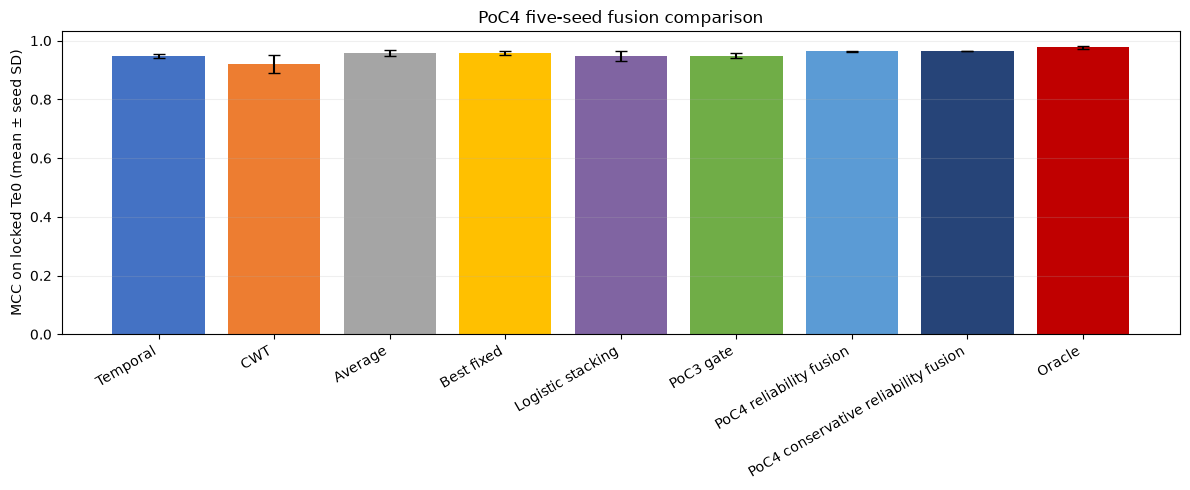

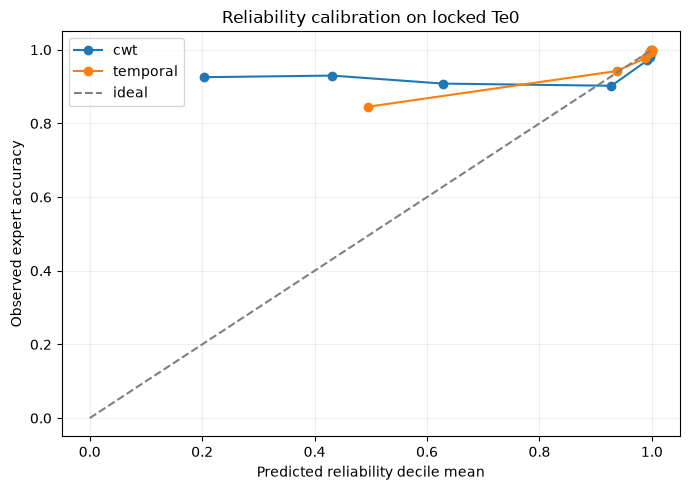

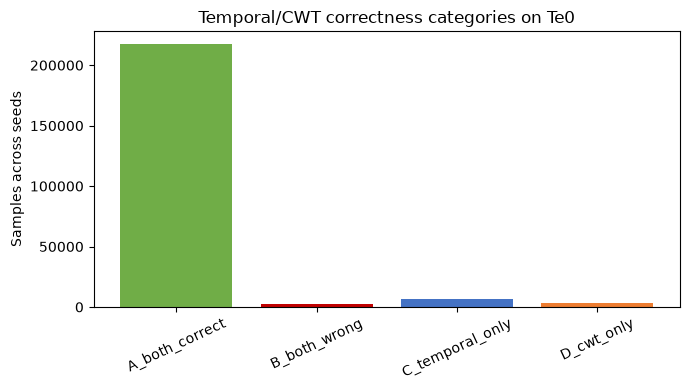


FINAL PoC4 VERDICT: NO-GO FOR ADAPTIVE FUSION
Primary adaptive vs fixed ΔMCC: 0.004862319289902062
Bootstrap 95% CI: [-0.004053090717128236, 0.019695135397100497]
Conservative adaptive vs fixed ΔMCC: 0.005032147613414928
Conservative bootstrap 95% CI: [-0.0014491293837330498, 0.01956622057667939]
Positive seeds: 4 / 5
Oracle MCC mean: 0.977151995772138 | headroom vs fixed: 0.018608896672594022
McNemar adaptive vs fixed: {'b_baseline_correct_adaptive_wrong': 652, 'c_baseline_wrong_adaptive_correct': 1211, 'exact_two_sided_p_value': 8.568592243273743e-39}
Te2 accessed: False


In [9]:
def mcc_fast(labels, prediction):
    labels, prediction = np.asarray(labels, dtype=np.int64), np.asarray(prediction, dtype=np.int64)
    tp = int(np.sum((labels == 1) & (prediction == 1)))
    tn = int(np.sum((labels == 0) & (prediction == 0)))
    fp = int(np.sum((labels == 0) & (prediction == 1)))
    fn = int(np.sum((labels == 1) & (prediction == 0)))
    denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return float((tp * tn - fp * fn) / denominator) if denominator else 0.0

def paired_bootstrap_for_methods(method_a, method_b, seed_offset):
    rows = []
    for seed_index, seed in enumerate(SEEDS):
        rng = np.random.default_rng(20260902 + seed_offset + seed_index)
        pred_a = test_runs[seed]['predictions'][method_a]
        pred_b = test_runs[seed]['predictions'][method_b]
        for replicate in range(N_BOOTSTRAP_PER_SEED):
            index = rng.integers(0, len(y_test), len(y_test))
            rows.append({'comparison': f'{method_a} - {method_b}', 'seed': seed, 'replicate': replicate, 'delta_mcc': mcc_fast(y_test[index], pred_a[index]) - mcc_fast(y_test[index], pred_b[index])})
    return pd.DataFrame(rows)

bootstrap_df = pd.concat([
    paired_bootstrap_for_methods('PoC4 reliability fusion', 'Best fixed', 100),
    paired_bootstrap_for_methods('PoC4 reliability fusion', 'Temporal', 200),
    paired_bootstrap_for_methods('PoC4 conservative reliability fusion', 'Best fixed', 300),
    paired_bootstrap_for_methods('PoC4 conservative reliability fusion', 'Temporal', 400),
], ignore_index=True)

def bootstrap_summary(frame):
    values = frame['delta_mcc'].to_numpy()
    return {
        'comparison': frame['comparison'].iloc[0], 'n_bootstrap': int(len(values)),
        'mean': float(values.mean()), 'median': float(np.median(values)),
        'ci_95': [float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))],
        'fraction_gt_zero': float(np.mean(values > 0)),
    }

bootstrap_summary_rows = [bootstrap_summary(group) for _, group in bootstrap_df.groupby('comparison')]
bootstrap_df.to_csv(RESULT_DIR / 'poc4_bootstrap_deltas.csv', index=False)

def pooled_mcnemar(method_a, method_b):
    b = c = 0
    for seed in SEEDS:
        pred_a = test_runs[seed]['predictions'][method_a]
        pred_b = test_runs[seed]['predictions'][method_b]
        correct_a, correct_b = pred_a == y_test, pred_b == y_test
        b += int(np.sum(correct_b & ~correct_a))
        c += int(np.sum(~correct_b & correct_a))
    p_value = float(binomtest(min(b, c), b + c, 0.5, alternative='two-sided').pvalue) if b + c else 1.0
    return {'b_baseline_correct_adaptive_wrong': b, 'c_baseline_wrong_adaptive_correct': c, 'exact_two_sided_p_value': p_value}

mcnemar_results = {
    'adaptive_vs_fixed': pooled_mcnemar('PoC4 reliability fusion', 'Best fixed'),
    'adaptive_vs_temporal': pooled_mcnemar('PoC4 reliability fusion', 'Temporal'),
    'conservative_adaptive_vs_fixed': pooled_mcnemar('PoC4 conservative reliability fusion', 'Best fixed'),
    'conservative_adaptive_vs_temporal': pooled_mcnemar('PoC4 conservative reliability fusion', 'Temporal'),
}

aggregate = metrics_df.groupby('Method').agg(
    MCC=('mcc', 'mean'), MCC_std=('mcc', 'std'), Recall_PD=('recall_tpr', 'mean'), Recall_std=('recall_tpr', 'std'),
    F1=('f1', 'mean'), Accuracy=('accuracy', 'mean'), Errors=('errors', 'mean'),
).reset_index()
temporal_mcc = float(aggregate.loc[aggregate['Method'] == 'Temporal', 'MCC'].iloc[0])
fixed_mcc = float(aggregate.loc[aggregate['Method'] == 'Best fixed', 'MCC'].iloc[0])
aggregate['Delta_vs_Temporal'] = aggregate['MCC'] - temporal_mcc
aggregate['Delta_vs_Fixed'] = aggregate['MCC'] - fixed_mcc
aggregate = aggregate.set_index('Method').loc[METHOD_ORDER].reset_index()
aggregate.to_csv(RESULT_DIR / 'poc4_multi_seed_summary.csv', index=False)
display(aggregate[['Method', 'MCC', 'MCC_std', 'Recall_PD', 'F1', 'Errors', 'Delta_vs_Temporal', 'Delta_vs_Fixed']])

per_seed_pivot = metrics_df.pivot(index='seed', columns='Method', values='mcc').reset_index()
per_seed_pivot['Delta_adaptive_minus_fixed'] = per_seed_pivot['PoC4 reliability fusion'] - per_seed_pivot['Best fixed']
per_seed_pivot.to_csv(RESULT_DIR / 'poc4_per_seed_delta_table.csv', index=False)
display(per_seed_pivot[['seed', 'Temporal', 'CWT', 'Best fixed', 'PoC3 gate', 'PoC4 reliability fusion', 'PoC4 conservative reliability fusion', 'Delta_adaptive_minus_fixed']])

oracle_rows = []
for seed in SEEDS:
    oracle_pred = test_runs[seed]['predictions']['Oracle']
    fixed_pred = test_runs[seed]['predictions']['Best fixed']
    oracle_rows.append({
        'seed': seed,
        'oracle_mcc': mcc_fast(y_test, oracle_pred),
        'best_fixed_mcc': mcc_fast(y_test, fixed_pred),
        'oracle_headroom_vs_fixed': mcc_fast(y_test, oracle_pred) - mcc_fast(y_test, fixed_pred),
    })
oracle_df = pd.DataFrame(oracle_rows)
oracle_df.to_csv(RESULT_DIR / 'poc4_oracle_headroom.csv', index=False)

primary_bootstrap = next(row for row in bootstrap_summary_rows if row['comparison'] == 'PoC4 reliability fusion - Best fixed')
conservative_bootstrap = next(row for row in bootstrap_summary_rows if row['comparison'] == 'PoC4 conservative reliability fusion - Best fixed')
adaptive_seed_deltas = per_seed_pivot['Delta_adaptive_minus_fixed'].to_numpy()
conservative_seed_deltas = per_seed_pivot['PoC4 conservative reliability fusion'] - per_seed_pivot['Best fixed']
positive_seed_count = int(np.sum(adaptive_seed_deltas > 0))
chosen_quality = pd.DataFrame(seed_reliability_quality_rows)
chosen_quality = chosen_quality[chosen_quality.apply(lambda row: row['model'] == frozen_configs[int(row['seed'])][f"reliability_model_{row['expert']}"], axis=1)]
reliability_auc_mean = float(chosen_quality['roc_auc'].mean()) if len(chosen_quality) else float('nan')
reliability_signal = bool(reliability_auc_mean > 0.55)
transition_aggregate = transition_df.groupby('comparison')[['corrected_by_adaptive', 'introduced_by_adaptive', 'unchanged', 'net_error_reduction']].sum().reset_index()
fixed_transition = transition_aggregate.loc[transition_aggregate['comparison'] == 'Adaptive vs Fixed'].iloc[0]
net_error_reduction = int(fixed_transition['net_error_reduction'])
adaptive_recall = float(aggregate.loc[aggregate['Method'] == 'PoC4 reliability fusion', 'Recall_PD'].iloc[0])
fixed_recall = float(aggregate.loc[aggregate['Method'] == 'Best fixed', 'Recall_PD'].iloc[0])
recall_safe = bool(adaptive_recall >= fixed_recall - 0.01)
ci_above_zero = bool(primary_bootstrap['ci_95'][0] > 0)
strong_go = bool(np.mean(adaptive_seed_deltas) >= 0.005 and ci_above_zero and positive_seed_count >= 4 and net_error_reduction > 0 and reliability_signal and recall_safe)
moderate_go = bool(not strong_go and np.mean(adaptive_seed_deltas) >= 0.002 and ci_above_zero and positive_seed_count >= 4 and reliability_signal and recall_safe)
final_verdict = 'STRONG GO' if strong_go else ('MODERATE GO' if moderate_go else 'NO-GO FOR ADAPTIVE FUSION')
decision = {
    'verdict': final_verdict,
    'primary_method': 'PoC4 reliability fusion',
    'primary_delta_mean_mcc_vs_fixed': float(np.mean(adaptive_seed_deltas)),
    'primary_delta_std_across_seeds': float(np.std(adaptive_seed_deltas, ddof=1)),
    'primary_bootstrap': primary_bootstrap,
    'positive_seed_count': positive_seed_count,
    'n_seeds': len(SEEDS),
    'conservative_delta_mean_mcc_vs_fixed': float(conservative_seed_deltas.mean()),
    'conservative_bootstrap': conservative_bootstrap,
    'conservative_positive_seed_count': int(np.sum(conservative_seed_deltas > 0)),
    'reliability_auc_mean_selected_va0': reliability_auc_mean,
    'reliability_signal_mean_auc_gt_0.55': reliability_signal,
    'net_error_reduction_vs_fixed': net_error_reduction,
    'adaptive_recall_mean': adaptive_recall,
    'fixed_recall_mean': fixed_recall,
    'recall_safe_within_1pp': recall_safe,
    'criteria': {
        'strong_delta_ge_0.005': bool(np.mean(adaptive_seed_deltas) >= 0.005),
        'bootstrap_ci_above_zero': ci_above_zero,
        'at_least_4_of_5_seeds_positive': bool(positive_seed_count >= 4),
        'net_error_reduction': bool(net_error_reduction > 0),
        'meaningful_reliability': reliability_signal,
        'no_important_recall_degradation': recall_safe,
    },
    'interpretation': 'This decision concerns added value of sample-wise reliability over best fixed fusion; it does not reject complementary temporal/CWT fusion.',
}

fig, ax = plt.subplots(figsize=(12, 5))
plot_data = aggregate.set_index('Method').loc[METHOD_ORDER]
ax.bar(np.arange(len(plot_data)), plot_data['MCC'], yerr=plot_data['MCC_std'].fillna(0), capsize=4, color=['#4472c4', '#ed7d31', '#a5a5a5', '#ffc000', '#8064a2', '#70ad47', '#5b9bd5', '#264478', '#c00000'])
ax.set_xticks(np.arange(len(plot_data)), plot_data.index, rotation=30, ha='right')
ax.set_ylabel('MCC on locked Te0 (mean ± seed SD)')
ax.set_title('PoC4 five-seed fusion comparison')
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc4_multi_seed_mcc.png', dpi=150)
display(fig)
plt.close(fig)

bin_plot = reliability_bins_df.groupby(['expert', 'bin'], as_index=False).agg(predicted_reliability=('predicted_reliability', 'mean'), observed_accuracy=('observed_accuracy', 'mean'))
fig, ax = plt.subplots(figsize=(7, 5))
for expert, group in bin_plot.groupby('expert'):
    ax.plot(group['predicted_reliability'], group['observed_accuracy'], marker='o', label=expert)
ax.plot([0, 1], [0, 1], '--', color='gray', label='ideal')
ax.set_xlabel('Predicted reliability decile mean')
ax.set_ylabel('Observed expert accuracy')
ax.set_title('Reliability calibration on locked Te0')
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc4_reliability_quality.png', dpi=150)
display(fig)
plt.close(fig)

category_plot = disagreement_df.groupby('category', as_index=False)['n'].sum()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(category_plot['category'], category_plot['n'], color=['#70ad47', '#c00000', '#4472c4', '#ed7d31'])
ax.set_ylabel('Samples across seeds')
ax.set_title('Temporal/CWT correctness categories on Te0')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc4_disagreement_categories.png', dpi=150)
display(fig)
plt.close(fig)

provenance = {
    'dataset_id': DATASET_ID, 'dataset_version': DATASET_VERSION,
    'catalog_root_from_environment': 'PD_DATASETS_CATALOG_ROOT',
    'python': sys.version, 'numpy': np.__version__, 'pandas': pd.__version__, 'torch': torch.__version__,
    'device': str(DEVICE), 'repository_commit': git_commit(),
    'loaded_partitions': loaded_partitions, 'te2_accessed': FORBIDDEN_PARTITION in loaded_partitions,
    'oof_source': 'poc3_gate_oof_predictions.csv; five-fold cross-fitted Tr0 logits; row identity checked',
    'bootstrap_replicates_per_seed_per_comparison': N_BOOTSTRAP_PER_SEED,
    'bootstrap_replicates_per_comparison': N_BOOTSTRAP_TOTAL,
}
summary = {
    'poc': 'poc4-reliability-aware-adaptive-fusion',
    'objective': 'Test sample-wise reliability value over optimally tuned fixed fusion.',
    'protocol': frozen_config['protocol'],
    'frozen_config_file': 'poc4_frozen_config.json',
    'final_te0_aggregate': aggregate.reset_index(drop=True).to_dict(orient='records'),
    'per_seed_metrics': metrics_df.to_dict(orient='records'),
    'per_seed_delta_table': per_seed_pivot.to_dict(orient='records'),
    'oracle': oracle_df.to_dict(orient='records'),
    'oracle_mean_mcc': float(oracle_df['oracle_mcc'].mean()),
    'oracle_mean_headroom_vs_fixed': float(oracle_df['oracle_headroom_vs_fixed'].mean()),
    'bootstrap': bootstrap_summary_rows,
    'mcnemar': mcnemar_results,
    'transitions': transition_aggregate.to_dict(orient='records'),
    'reliability_quality_oof_crossfit': oof_reliability_quality.to_dict(orient='records'),
    'reliability_quality_va0': pd.DataFrame(seed_reliability_quality_rows).to_dict(orient='records'),
    'decision': decision,
    'provenance': provenance,
    'artifacts': [
        'poc4_frozen_config.json', 'poc4_per_seed_metrics.csv', 'poc4_multi_seed_summary.csv',
        'poc4_per_seed_delta_table.csv', 'poc4_te0_predictions.csv.gz', 'poc4_oof_reliability_features.csv.gz',
        'poc4_bootstrap_deltas.csv', 'poc4_error_transitions.csv', 'poc4_disagreement_analysis.csv',
        'poc4_reliability_bins.csv', 'poc4_distribution_shift.csv', 'poc4_calibration.csv',
        'poc4_reliability_quality_va0.csv', 'poc4_multi_seed_mcc.png', 'poc4_reliability_quality.png',
        'poc4_disagreement_categories.png',
    ],
    'te2_statement': 'Te2 is reserved for a future confirmatory experiment and was not accessed in PoC4.',
}
(RESULT_DIR / 'poc4_summary.json').write_text(json.dumps(summary, indent=2, sort_keys=True, default=str))
print('\nFINAL PoC4 VERDICT:', final_verdict)
print('Primary adaptive vs fixed ΔMCC:', decision['primary_delta_mean_mcc_vs_fixed'])
print('Bootstrap 95% CI:', primary_bootstrap['ci_95'])
print('Conservative adaptive vs fixed ΔMCC:', decision['conservative_delta_mean_mcc_vs_fixed'])
print('Conservative bootstrap 95% CI:', conservative_bootstrap['ci_95'])
print('Positive seeds:', positive_seed_count, '/', len(SEEDS))
print('Oracle MCC mean:', summary['oracle_mean_mcc'], '| headroom vs fixed:', summary['oracle_mean_headroom_vs_fixed'])
print('McNemar adaptive vs fixed:', mcnemar_results['adaptive_vs_fixed'])
print('Te2 accessed:', provenance['te2_accessed'])

## Final interpretation and next step

The decision above is intentionally about the incremental value of
reliability-aware adaptation over the best fixed fusion. The result
should be reported together with the oracle headroom, reliability
prediction quality, seed-by-seed deltas, error transitions, and the
calibration/shift tables. If the outcome is GO, the next action is to
freeze this exact pipeline and run a separate confirmatory experiment
on untouched `Te2`, followed by external validation. If it is NO-GO,
stop optimizing adaptive gates and preserve any successful static
multimodal fusion result as the contribution.